# Bond dirty and clean price 


In [28]:
import math
import numpy as np
import pandas as pd
import datetime as dt
from matplotlib import pyplot as plt
from abc import ABCMeta, abstractmethod

In [54]:
class FIProduct(metaclass=ABCMeta):
    @abstractmethod
    def PV(self):
        raise NotImplementedError

class Bond(FIProduct):
    def __init__(self, cash_flows: pd.Series, face_value: float, r: pd.Series, settlement: dt.datetime):
        self.cf = cash_flows  # index is dt.datetime
        self.fv = face_value
        self.r = r
        self.settlement = settlement
        self.T = cash_flows.index.max()
        # Derive frequency from average spacing between coupon dates
        dates = cash_flows.index.tolist()
        if len(dates) > 1:
            diffs = [(dates[i] - dates[i - 1]).days for i in range(1, len(dates))]
            self.f = (sum(diffs) / len(diffs)) / 365.0
        else:
            self.f = (dates[0] - settlement).days / 365.0
        self.c = (cash_flows.iloc[-1] / face_value - 1.0) / self.f
        self.pv = self.PV()

    def _to_years(self, date: dt.datetime) -> float:
        """Year fraction from settlement to date."""
        return (date - self.settlement).days / 365.0

    def PV(self, r=None, t_shift: dt.timedelta = dt.timedelta(days=0)):
        if r is None:
            r = self.r
        assert len(r) == len(self.cf)
        table = pd.DataFrame(dtype=float)
        table["cf"] = self.cf.values
        table["r"] = r.values
        table["t"] = [(date - self.settlement - t_shift).days / 365.0
                      for date in self.cf.index]
        table = table.loc[table['t'] > 0.]
        return table.apply(
            lambda row: row["cf"] / (1 + row["r"]) ** row["t"], axis=1
        ).sum()

    def accrued(self, t_shift: dt.timedelta)->float:
        table = pd.DataFrame(dtype=float)
        table["cf"] = self.cf.values
        table["r"] = self.r.values
        table["t"] = [(date - self.settlement - t_shift).days / 365.0
                      for date in self.cf.index]
        previous_coupon = table.loc[table['t'] < 0.].iloc[-1]
        next_coupon = table.loc[table['t'] > 0.].iloc[0]
        t_previous = float(previous_coupon['t'])
        t_next = float(next_coupon['t'])
        t_current = 0.
        accrued_fraction = (t_current - t_previous) / (t_next - t_previous)
        cash_flow = float(previous_coupon['cf'])
        return  accrued_fraction * cash_flow * (1. + float(next_coupon['r'])) ** t_next 

    def get_yield(self, precision=1e-4):
        cf_df = self.cf.reset_index()
        t_years = [self._to_years(d) for d in cf_df["schedule"]]
        func = (
            lambda y: sum(
                float(cf) / (1 + y) ** t
                for cf, t in zip(cf_df["cash flows"], t_years)
            ) - self.pv
        )
        y = find_root(func, precision)
        return y

    def get_price_from_yield(self, y: float):
        cf_df = self.cf.reset_index()
        t_years = [self._to_years(d) for d in cf_df["schedule"]]
        return sum(
            float(cf) / (1 + y) ** t
            for cf, t in zip(cf_df["cash flows"], t_years)
        )

    def PV01(self, delta_y: float = 1e-4):
        return self.get_price_from_yield(self.get_yield() + delta_y) - self.pv

    def DV01(self, delta_y: float = 1e-4):
        return self.PV(self.r + delta_y) - self.pv

    def plot_cash_flows(self, save: bool = False):
        plot = self.cf.plot(
            kind="bar", figsize=(8, 5), title="Cash Flows", grid=True, logy=True
        )
        if save:
            fig = plot.get_figure()
            fig.savefig("bond_cf.png")

    def DV01_drilldown(self, delta_y=1e-4):
        """Get the rate sensitivity for each maturity"""
        dv01x = []
        for t in self.r.index:
            uptick_t = self.r.copy()
            uptick_t.loc[t] += delta_y
            dv01_ = self.PV(uptick_t) - self.pv
            dv01x.append(dv01_)
        return pd.Series(dv01x, index=self.cf.index)


def generate_bond_cash_flows(face_value, coupon, frequency, maturity, start_date: dt.datetime):
    n = int(maturity / frequency)
    days_per_period = math.ceil(frequency * 365)
    dates = [start_date + dt.timedelta(days=k * days_per_period) for k in range(1, n + 1)]
    cash_flows = pd.Series([face_value * coupon / n] * n, index=dates, name="cash flows")
    cash_flows.iloc[-1] += face_value
    cash_flows.index.name = "schedule"
    return cash_flows


def find_root(fun, precision, x0=1.0):
    x = 0.01
    while np.abs(fun(x)) > precision and np.abs(fun(x) - fun(x0)) > precision:
        x, x0 = x - fun(x) * (x0 - x) / (fun(x0) - fun(x)), x
    return x

## Accrued and basis

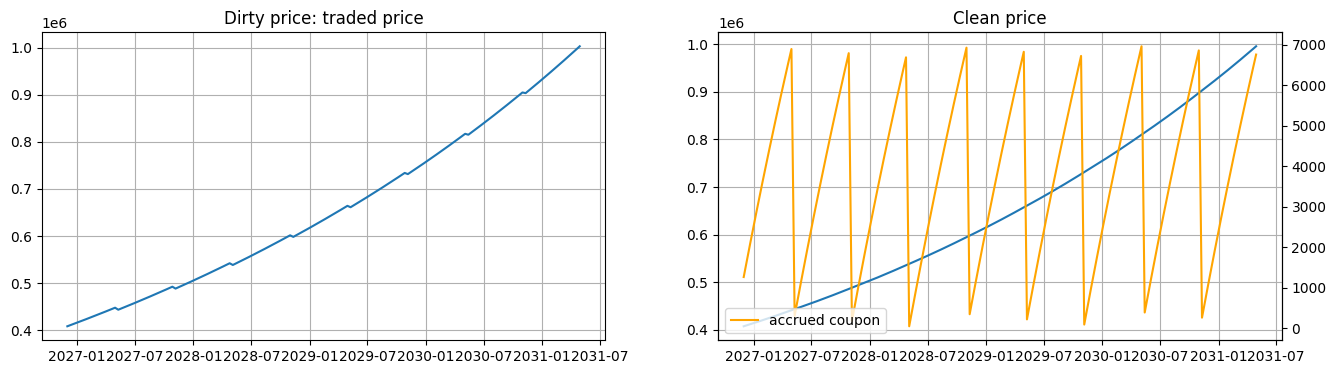

In [74]:
face_value = 1e6
coupon_rate = 7e-2
frequency = .5
maturity_years = 5

settlement_date = dt.datetime.today() + dt.timedelta(days=2)

cash_flows = generate_bond_cash_flows(
    face_value=face_value,
    coupon=coupon_rate,
    frequency=frequency,
    maturity=maturity_years,
    start_date=settlement_date
)
tx = cash_flows.index

r = pd.Series(
    [.25 + .0005 * np.sqrt(k) for k in range(len(tx))], index=tx, name="forward rate"
)

bond = Bond(
    cash_flows=cash_flows,
    face_value=face_value,
    r=r,
    settlement=settlement_date
)

pvx = []
clean_prices = []
time_range = pd.date_range(settlement_date+dt.timedelta(days=int(365*frequency)+31), settlement_date + dt.timedelta(days=365 * maturity_years), freq=dt.timedelta(days=10))
accruedx = []
for t in time_range:
    pvx.append(bond.PV(t_shift=t-settlement_date))
    accruedx.append(bond.accrued(t_shift=t-settlement_date))
    clean_prices.append(pvx[-1] - accruedx[-1])

fig, axs = plt.subplots(ncols=2, figsize=(16, 4))
ax1_twin = axs[1].twinx()
axs[0].plot(time_range, pvx)
axs[1].plot(time_range, clean_prices)
ax1_twin.plot(time_range, accruedx, color='orange', label='accrued coupon')
axs[0].grid()
axs[1].grid()
axs[0].set_title("Dirty price: traded price")
axs[1].set_title("Clean price")
_ = ax1_twin.legend()

## PV, Cash flows and PnL